
Маркетологи одного из фитнес-центров запустили акцию "Набегай на абонемент". Чтобы оценить, какой эффект коммуникация оказала на суммарную дистанцию клиентов на беговой дорожке (признак kms), было решено провести А/Б тестирование. Для этого выделили две группы (находятся в файлах group_a.csv и group_b.csv). Коммуникацию отправляли только клиентам из группы b. Ваша задача - оценить успехи маркетологов (в проведении теста).

**Задачи:**

- Проанализировать результаты теста: как изменилось количество километров у клиентов, которым отправили коммуникацию? Сделать это с помощью t-теста (используя функцию scipy.stats.ttest_ind), а затем с помощью бутстрапа (реализовать самостоятельно)

- Определить минимальный размер эффекта, который можно задетектировать на данных группах при уровне значимости 0.05 и мощности 0.8. Нужно сделать это двумя способами: используя функцию statsmodels.stats.power.tt_ind_solve_power и по формуле, упомянутой во 2 разделе. Результаты должны получиться похожими.



Данные:

[data.csv](https://buildin.ai/preview/fee3979d-344c-4c44-ad96-eadb746cba6b)

[group_a.csv](https://buildin.ai/preview/5ac88d3f-8490-44cd-8bc7-5277dda27d9e)

[group_b.csv](https://buildin.ai/preview/49ade326-5f7b-4e58-89e2-2df3a25c66d1)



In [1]:
# import framworks
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
import numpy as np
from random import choice as random_choice
import statsmodels as stm

In [2]:
data = pd.read_csv('data.csv')
group_a = pd.read_csv('group_a.csv')
group_b = pd.read_csv('group_b.csv')

**План анализа**

1. Первичный анализ даных (EDA)
    * Просмотр строк, размерность и тип.
    * Проверка на пропуски и нулевые знание.
    * Проверка на выбросы и нормальность рапредления.
    * Посчитать базовые статистики ( медина, средние, стандартное отклонение )

2. Проверка корректности А/Б Теста 
    * Группы сравнивание по размеру (n_a и n_b)
    * Нет системный отличий до 
    * Есть ли у нас увереность что группы сформированы случайно

3. Проведение т-теста
    * Выдвинуть нулевую гипотезу
    * Выбрать уровень значимости 
    * Проверить t_test_ind
    * Интерпиритовать p_value

4. Бустап
    * Многократно извлеккать выборки из каждой групп
    * Каждый раз вычислять разность средний ( В - А )
    * Получить распределение по этой разници
    * Посмотреть где нахоиться 0 относительно этого распределниея

5. Минимальный детектируемый эффект (MDE)
    * Какой минимальный реальный эффект мы могли бы заметить при заданных размерах групп, α=0.05 и мощности 0.8
    

# Первичный анализ данных


In [3]:
# подтягивание кмс из даты к группам
merged_group_a = group_a.merge(data, how='left')
merged_group_b = group_b.merge(data, how='left')

In [4]:
# просмотр строк group_a

merged_group_a.head()

,user_id,kms
0,31543,47.19
1,16425,40.34
2,76147,90.41
3,47054,98.00
4,97312,72.96


In [5]:
# просмотр строк group_b

merged_group_b.head()

,user_id,kms
0,27009,22.82
1,79472,27.78
2,62051,48.94
3,24388,46.05
4,15982,34.16


In [6]:
# тип данных группы а и б 
print(f'Тип данных групп а {merged_group_a.info()}')
print(f'Тип данных групп б {merged_group_b.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  2000 non-null   int64  
 1   kms      2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
Тип данных групп а None
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  2000 non-null   int64  
 1   kms      2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
Тип данных групп б None


кол-во строк и тип данных у групп совпадает


In [7]:
# проверка групп на нулевыые значения и выбросы

print(f'Группа А содержит пропусков: {merged_group_a.isna().sum()}, нулевых значений: {group_a.isnull().sum()}')
print(f'Группа А содержит пропусков: {merged_group_b.isna().sum()}, нулевых значений: {group_b.isnull().sum()}')

Группа А содержит пропусков: user_id    0
kms        0
dtype: int64, нулевых значений: user_id    0
dtype: int64
Группа А содержит пропусков: user_id    0
kms        0
dtype: int64, нулевых значений: user_id    0
dtype: int64


Пропусков и нулевых значений не обнаружено


In [8]:
# описательная статистика: среднее , стандартное отклонение для группы а
merged_group_a['kms'].describe()

count    2000.000000
mean       50.515335
std        28.858953
min         0.000000
25%        25.010000
50%        52.010000
75%        74.975000
max       102.160000
Name: kms, dtype: float64

В группе А средняя дистанция составила 50.52 км при стандартном отклонении 28.86 км. Медиана (52.01 км) близка к среднему, что указывает на умеренно симметричное распределение. Минимальное значение — 0 км (клиенты не бегали), максимальное — 102.16 км. Значение на 75-м перцентиле — 74.98 км; максимум превышает его примерно в 1.36 раза, что не говорит о сильных выбросах.

In [9]:
# описательная статистика: среднее , стандартное отклонение для группы б
merged_group_b.kms.describe()

count    2000.000000
mean       50.815185
std        29.418566
min         0.000000
25%        24.942500
50%        50.920000
75%        76.900000
max       103.710000
Name: kms, dtype: float64

В группе В средняя дистанция — 50.82 км, std — 29.42 км. Медиана (50.92 км) практически совпадает со средним. Минимум — 0 км, максимум — 103.71 км. 75-й перцентиль = 76.90 км, максимум выше него в 1.35 раза — выбросов не наблюдается.



В группе В средняя дистанция — 50.82 км, std — 29.42 км. Медиана (50.92 км) практически совпадает со средним. Минимум — 0 км, максимум — 103.71 км. 75-й перцентиль = 76.90 км, максимум выше него в 1.35 раза — выбросов не наблюдается.



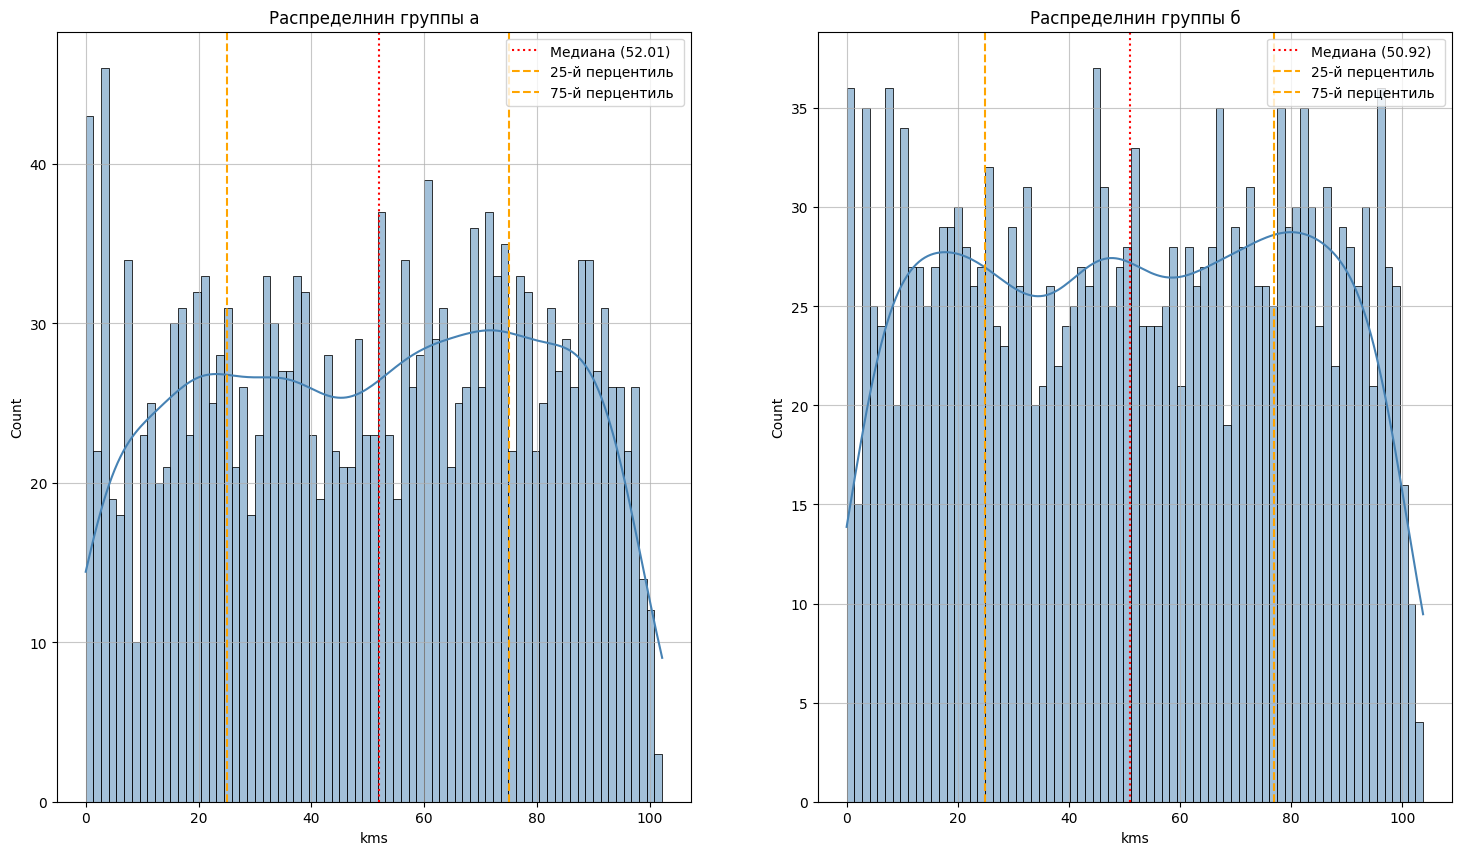

In [10]:
# построение графиков распределние
plt.figure(figsize=(18,10))
plt.subplot(1,2,1)
# график для группы а 

sns.histplot(
    data = merged_group_a,
    x = merged_group_a.kms,
    kde=True,
    bins = 75,
    color = 'steelblue'
    
)
plt.axvline(
    merged_group_a.kms.median(), 
    color = 'red', 
    linestyle = 'dotted', 
    label = f'Медиана ({ merged_group_a.kms.median():.2f})'
    )
plt.axvline(
    merged_group_a.kms.quantile(0.25), 
    color = 'orange',
    linestyle = 'dashed',
    label = '25-й перцентиль ')
plt.axvline(
    merged_group_a.kms.quantile(0.75), 
    color = 'orange',
    linestyle = 'dashed',
    label = '75-й перцентиль ')
plt.title('Распределнин группы а')
plt.grid(alpha=0.7)
plt.legend()


plt.subplot(1, 2, 2)
# график для группы б
sns.histplot(
    data = merged_group_b,
    x = merged_group_b.kms,
    kde=True,
    bins = 75,
    color = 'steelblue'
    
)
plt.axvline(
    merged_group_b.kms.median(), 
    color = 'red', 
    linestyle = 'dotted', 
    label = f'Медиана ({ merged_group_b.kms.median()})'
    )
plt.axvline(
    merged_group_b.kms.quantile(0.25), 
    color = 'orange',
    linestyle = 'dashed',
    label = '25-й перцентиль ')
plt.axvline(
    merged_group_b.kms.quantile(0.75), 
    color = 'orange',
    linestyle = 'dashed',
    label = '75-й перцентиль ')
plt.title('Распределнин группы б')
plt.grid(alpha=0.7)
plt.legend()
plt.show()

Распределение дистанции (kms) в обеих группах является двумодальным: наблюдаются два основных пика — в районе 0–10 км и 50–70 км. В обеих группах присутствуют клиенты с нулевыми значениями (не бегали), а также длинный правый хвост. Медианы групп практически совпадают: 50.01 км (группа А) и 50.92 км (группа В) — разница составляет 0.91 км. Выбросы не носят аномального характера, распределения групп визуально очень похожи.

<Axes: >

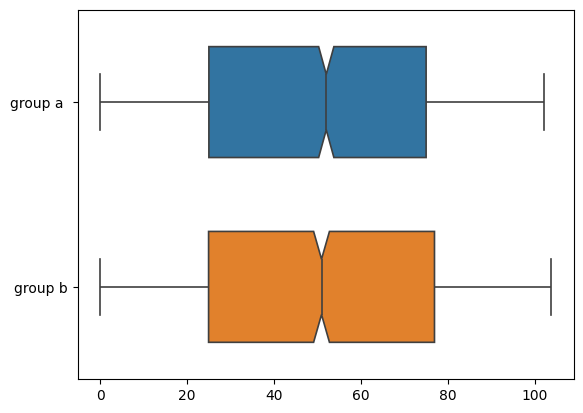

In [11]:
# проверка на выбосы через боксплот

# список групп 
group_dict = {
    'group a ' : merged_group_a.kms,
    'group b' : merged_group_b.kms
}

sns.boxplot(
    data=group_dict,
    orient='h',                 
    notch=True,           
    width=0.6,           
    fliersize=2,         
    linewidth=1.2         
)

Боксплот показывает что выбросы отсуствуют, мои опасения на графике распределние оказилсь ложными. Доверительные интервалы пересекаютсья , группы статически не различимы для т-теста ожидаеться что  p_value будет скорее всего выше 5% и нулевую гипотезу не отклонишь

# Проверка размера групп

In [12]:
# проверка размера групп
print(f'Размер группы а после соеденние {len(merged_group_a)}')
print(f'Размер группы b после соеденние {len(merged_group_b)}')
print(f'Различие в размере групп {len(merged_group_a)  - len(merged_group_b)}')

Размер группы а после соеденние 2000
Размер группы b после соеденние 2000
Различие в размере групп 0


In [13]:
# Проверить, все ли значения из группы A есть в итоговой таблице
set_a = set(group_a.user_id)  
set_res = set(merged_group_a.user_id)

# Какие из A не попали
missing = set_a - set_res


# Количество потерянных
print(f"Всего в A: {len(set_a)}")
print(f"Попали в итог: {len(set_a & set_res)}")
print(f"Потеряно: {len(missing)}")

Всего в A: 1976
Попали в итог: 1976
Потеряно: 0


In [14]:
# Проверить, все ли значения из группы Б есть в итоговой таблице
set_b = set(group_b.user_id)  
set_res = set(merged_group_b.user_id)

# Какие из A не попали
missing = set_b - set_res


# Количество потерянных
print(f"Всего в Б: {len(set_b)}")
print(f"Попали в итог: {len(set_b & set_res)}")
print(f"Потеряно: {len(missing)}")

Всего в Б: 1991
Попали в итог: 1991
Потеряно: 0


Принято решение удалить клиентов попавших в обе группы, 44 по сравнение с 2000 не критическое кол-во

In [15]:
merged_group_a = merged_group_a[~merged_group_a['user_id'].isin(set_a.intersection(set_b))]
merged_group_b = merged_group_b[~merged_group_b['user_id'].isin(set_a.intersection(set_b))]

In [16]:
# проверка размера групп после удаления
print(f'Размер группы а после соеденние {len(merged_group_a)}')
print(f'Размер группы b после соеденние {len(merged_group_b)}')
print(f'Различие в размере групп {len(merged_group_a)  - len(merged_group_b)}')

Размер группы а после соеденние 1955
Размер группы b после соеденние 1956
Различие в размере групп -1


In [17]:
# Проверить дубликаты по user_id в группе а
duplicates = merged_group_a['user_id'].duplicated().sum()
print(f"Дубликатов по user_id: {duplicates}")

# Сравнить длины
len_all = len(merged_group_a)
len_unique = merged_group_a['user_id'].nunique()
print(f"Всего строк: {len_all}")
print(f"Уникальных user_id: {len_unique}")

if len_all == len_unique:
    print("Длинны совпадают, дубликатов нет")
else:
    print("Есть дубликаты, нужно обработать")

Дубликатов по user_id: 23
Всего строк: 1955
Уникальных user_id: 1932
Есть дубликаты, нужно обработать


In [18]:
# Проверить дубликаты по user_id в группе б
duplicates = merged_group_b['user_id'].duplicated().sum()
print(f"Дубликатов по user_id: {duplicates}")

# Сравнить длины
len_all = len(merged_group_b)
len_unique = merged_group_b['user_id'].nunique()
print(f"Всего строк: {len_all}")
print(f"Уникальных user_id: {len_unique}")

if len_all == len_unique:
    print("Длинны совпадают, дубликатов нет")
else:
    print("Есть дубликаты, нужно обработать")

Дубликатов по user_id: 9
Всего строк: 1956
Уникальных user_id: 1947
Есть дубликаты, нужно обработать


In [19]:
# Усредняем kms для каждого user_id в рамках его группы a 
merged_group_a = merged_group_a.groupby(['user_id', 'kms'], as_index=False)['kms'].mean()

# Проверяем результат
print(f"После обработки: {len(merged_group_a)} строк")
print(f"Уникальных user_id: {merged_group_a['user_id'].nunique()}")

После обработки: 1932 строк
Уникальных user_id: 1932


In [20]:
# Усредняем kms для каждого user_id в рамках его группы б
merged_group_b = merged_group_b.groupby(['user_id', 'kms'], as_index=False)['kms'].mean()

# Проверяем результат
print(f"После обработки: {len(merged_group_b)} строк")
print(f"Уникальных user_id: {merged_group_b['user_id'].nunique()}")

После обработки: 1947 строк
Уникальных user_id: 1947


# Проведение т-теста


In [21]:
A = merged_group_a.kms
B = merged_group_b.kms

result = stats.ttest_ind(
    A,
    B
)
print(f't-статистика {result.statistic:.2}')
print(f'p-value {result.pvalue:.2}')


t-статистика -0.28
p-value 0.78


p-value (0.78) > α (0.05) → не отвергаем нулевую гипотезу о равенстве средних в генеральных совокупностях.


In [22]:
def bootstrap(
        A,
        B,
        count_iter = 10_000
):
    """
    Функия бутсрап принимает на вход:
    count_iter  - кол-во итераций для взятие выборок
    А - группа А
    В - группа В
    """
    result = []
    n = 0

    while n < count_iter:

        stack_a = [random_choice(A) for _ in range(1, len(A) + 1)]
        stack_b = [random_choice(B) for _ in range(1, len(B) + 1)]

        result.append( np.mean(stack_b) - np.mean(stack_a))
        n += 1

    return result

In [ ]:
result = bootstrap(
    A = merged_group_a.kms,
    B = merged_group_b.kms,
)

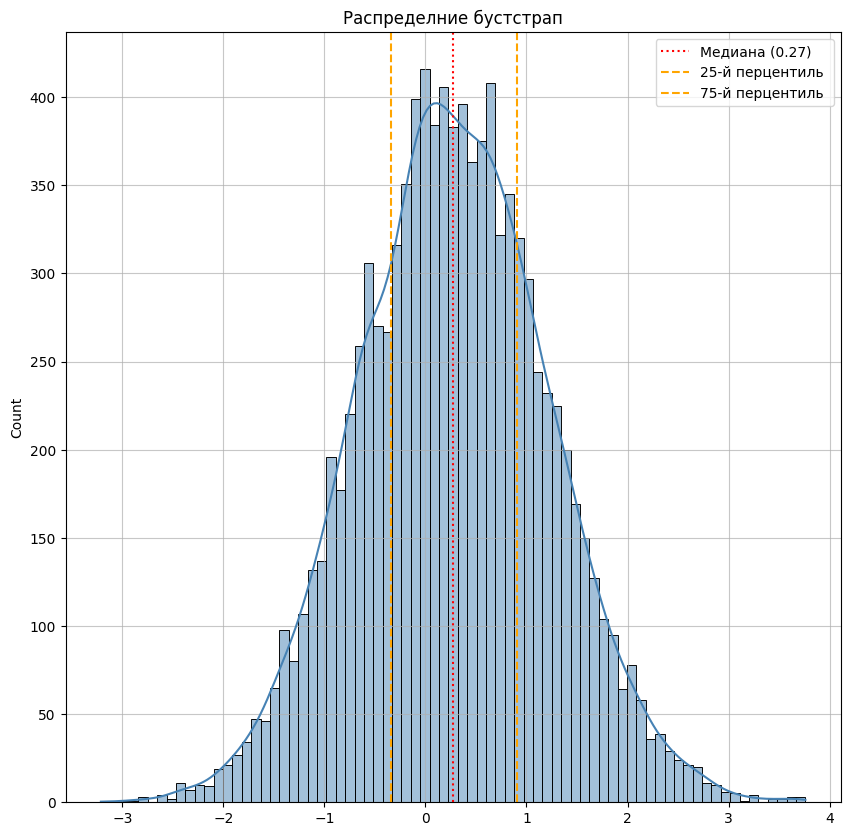

In [ ]:
plt.figure(figsize=(10,10))

sns.histplot(
    x = result,
    kde=True,
    bins = 75,
    color = 'steelblue'
)
plt.axvline(
    np.median(result), 
    color = 'red', 
    linestyle = 'dotted', 
    label = f'Медиана ({np.median(result):.2f})'
    )
plt.axvline(
    np.quantile(result,q = 0.25), 
    color = 'orange',
    linestyle = 'dashed',
    label = '25-й перцентиль ')
plt.axvline(
    np.quantile(result, q = 0.75), 
    color = 'orange',
    linestyle = 'dashed',
    label = '75-й перцентиль ')

plt.grid(alpha=0.7)
plt.legend()
plt.title('Распределние бустстрап')
plt.show()

Распределение разности средних (B — A), полученное методом бутстрапа, имеет медиану 0.26. Ноль (значение, соответствующее нулевой гипотезе) находится внутри интервала между 25-м и 75-м перцентилями. Это означает, что нулевая гипотеза о равенстве средних не противоречит данным. Результат бутстрапа согласуется с выводом t-теста (p-value = 0.78): статистически значимого эффекта коммуникации не обнаружено.

#  Минимальный детектируемый эффект (MDE)

In [ ]:
# MDE (Cohen's d) через ttest_ind_solve_power
from statsmodels.stats.power import tt_ind_solve_power

n_A = len(merged_group_a)
n_B = len(merged_group_b)
stm
effect_size = tt_ind_solve_power(
    nobs1 = n_A,
    ratio = n_B / n_A,
    alpha = 0.05,
    power = 0.80
)

print(f'Стандартизированная разница: {effect_size}')

Стандартизированная разница: 0.08998796901102468


In [ ]:
# nстандартное отклонение дух групп

std_a = np.std(merged_group_a.kms, ddof=1)
std_b = np.std(merged_group_b.kms, ddof=1)

In [ ]:
# объединённое стандартное отклонение
from math import sqrt
pooled_std = sqrt(((n_A-1)*std_a**2 + (n_B-1)*std_b**2) / (n_A + n_B - 2))
print(f'Объединённое стандартное отклонение (df={n_A+n_B-2}): {pooled_std:.3f}')

Объединённое стандартное отклонение (df=3877): 29.124


In [ ]:
# MDE (в км)
mde_value  = effect_size * pooled_std
print(f'Минимальный детектируемый эффект в км: {mde_value:.4f}')

Минимальный детектируемый эффект в км: 2.6208


С текущим размером групп (около 2000 человек), уровнем значимости 5% и мощностью 80% мы можем обнаружить минимальный эффект размером ~2.6 км.
Реальная разница средних составила 0.3 км, что меньше этого порога.
Поэтому, даже если бы акция работала, мы бы её не заметили в таком дизайне эксперимента.